# Image → Graphe par superpixels (Felzenszwalb)

Pour l'architecture **Physarum** (et tout modèle sur graphe), on convertit l'image MNIST en un **graphe** : chaque **superpixel** devient un **nœud**, et les superpixels **adjacents** sont reliés par des **arêtes**.

On utilise l'algorithme **Felzenszwalb** (`skimage.segmentation.felzenszwalb`) qui **s'adapte naturellement aux formes** de l'image — contrairement à SLIC qui impose une grille régulière. Les superpixels suivent les contours du chiffre.

## 0. Imports

In [1]:
# Conversion image -> graphe par superpixels + flux Physarum + classification
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb, mark_boundaries
from recherche_agi import (load_mnist, image_to_graph, superpixels,
    physarum_from_image, train_readout)
from recherche_agi.physarum import poiseuille_flow, run_physarum

## 1. Données : MNIST

In [2]:
train_set, test_set = load_mnist()
print("Train :", len(train_set), "| Test :", len(test_set))

Train : 60000 | Test : 10000


## 2. Segmentation en superpixels (Felzenszwalb)

Image 9 : 9 superpixels (image 28x28)


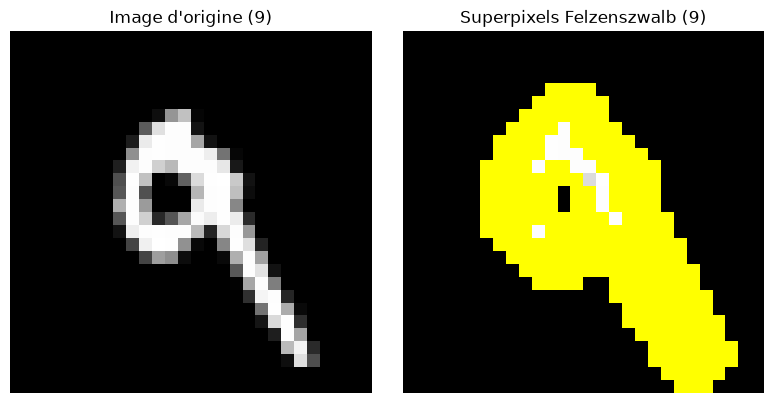

In [3]:
# Choisir une image (un '9')
img, label = test_set[7]
img_np = img.squeeze().numpy()

segments, n_labels = superpixels(img_np, scale=100, sigma=0.5, min_size=5)
print(f"Image {label} : {n_labels} superpixels (image 28x28)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f"Image d'origine ({label})")
axes[0].axis('off')
# normaliser pour l'affichage
lo, hi = img_np.min(), img_np.max()
img_01 = (img_np - lo) / (hi - lo + 1e-8)
axes[1].imshow(mark_boundaries(img_01, segments))
axes[1].set_title(f"Superpixels Felzenszwalb ({n_labels})")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Construction du graphe (nœuds = superpixels)

In [4]:
# Chaque superpixel = nœud ; superpixels adjacents = arêtes
g = image_to_graph(img_np, scale=100, sigma=0.5, min_size=5)
print(f"Graphe : {g['n_nodes']} nœuds, {g['n_edges']} arêtes")
print(f"Positions des nœuds (centroïdes) :\n{np.round(g['centroids'], 1)}")
print(f"Intensité moyenne par nœud (injection Physarum) : {[round(x,2) for x in g['intensities']]}")

Graphe : 9 nœuds, 17 arêtes
Positions des nœuds (centroïdes) :
[[13.1 13.2]
 [15.6 15.3]
 [13.9 13.3]
 [16.  10.5]
 [ 8.4 13.5]
 [11.8 12.5]
 [12.6 15.8]
 [17.4 16.8]
 [20.1 20.4]]
Intensité moyenne par nœud (injection Physarum) : [np.float64(0.0), np.float64(0.04), np.float64(0.92), np.float64(0.76), np.float64(0.3), np.float64(0.05), np.float64(0.62), np.float64(0.59), np.float64(0.38)]


## 4. Visualisation du graphe superposé à l'image

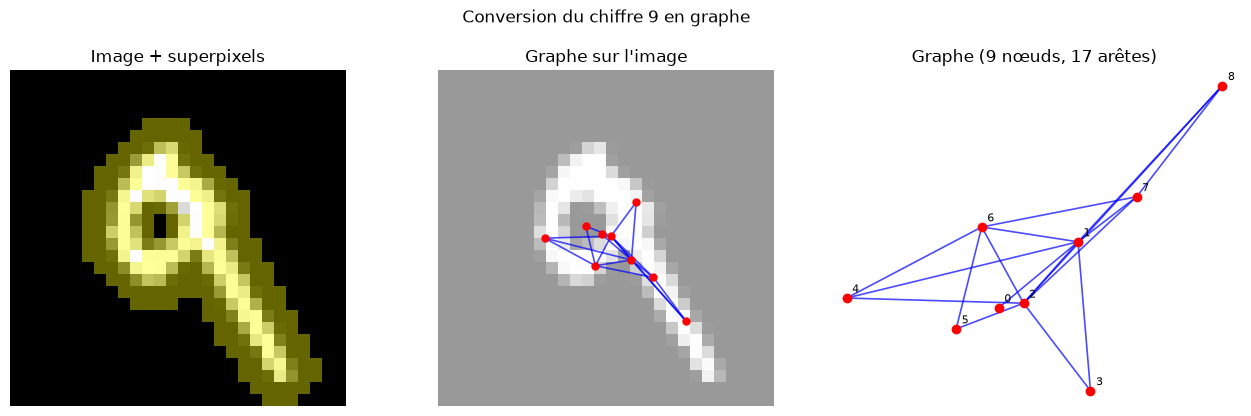

In [5]:
def plot_superpixel_graph(image, graph, title=""):
    """Affiche image + superpixels + graphe (nœuds et arêtes)."""
    img = np.asarray(image).squeeze()
    lo, hi = img.min(), img.max()
    img_01 = (img - lo) / (hi - lo + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
    # image + superpixels
    axes[0].imshow(img_01, cmap='gray')
    axes[0].imshow(mark_boundaries(img_01, graph['segments']), alpha=0.4)
    axes[0].set_title("Image + superpixels")
    axes[0].axis('off')
    # graphe sur image
    axes[1].imshow(img_01, cmap='gray', alpha=0.4)
    for (a, b) in graph['edges']:
        (x1, y1), (x2, y2) = graph['centroids'][a], graph['centroids'][b]
        axes[1].plot([x1, x2], [y1, y2], '-', color='blue', lw=1.2, alpha=0.7)
    for lab in range(graph['n_nodes']):
        x, y = graph['centroids'][lab]
        axes[1].plot(x, y, 'o', color='red', ms=5)
    axes[1].set_title("Graphe sur l'image")
    axes[1].axis('off')
    # graphe seul
    ax = axes[2]
    for (a, b) in graph['edges']:
        (x1, y1), (x2, y2) = graph['centroids'][a], graph['centroids'][b]
        ax.plot([x1, x2], [y1, y2], '-', color='blue', lw=1.2, alpha=0.7)
    for lab in range(graph['n_nodes']):
        x, y = graph['centroids'][lab]
        ax.plot(x, y, 'o', color='red', ms=6)
        ax.annotate(str(lab), (x, y), textcoords='offset points', xytext=(4, 4), fontsize=8)
    ax.set_title(f"Graphe ({graph['n_nodes']} nœuds, {graph['n_edges']} arêtes)")
    ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_superpixel_graph(img_np, g, title=f"Conversion du chiffre {label} en graphe")

## 5. Plusieurs chiffres

Chiffre 2 : 14 nœuds, 30 arêtes


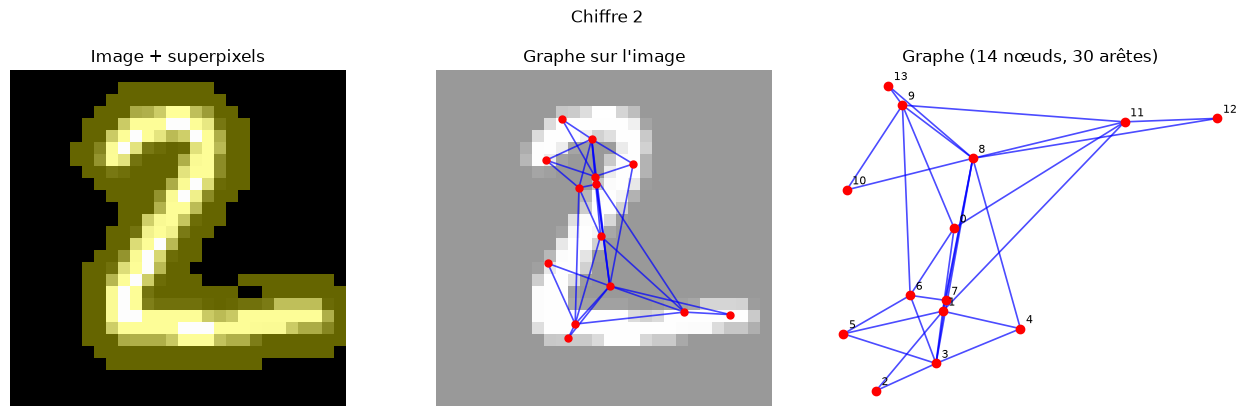

Chiffre 0 : 14 nœuds, 30 arêtes


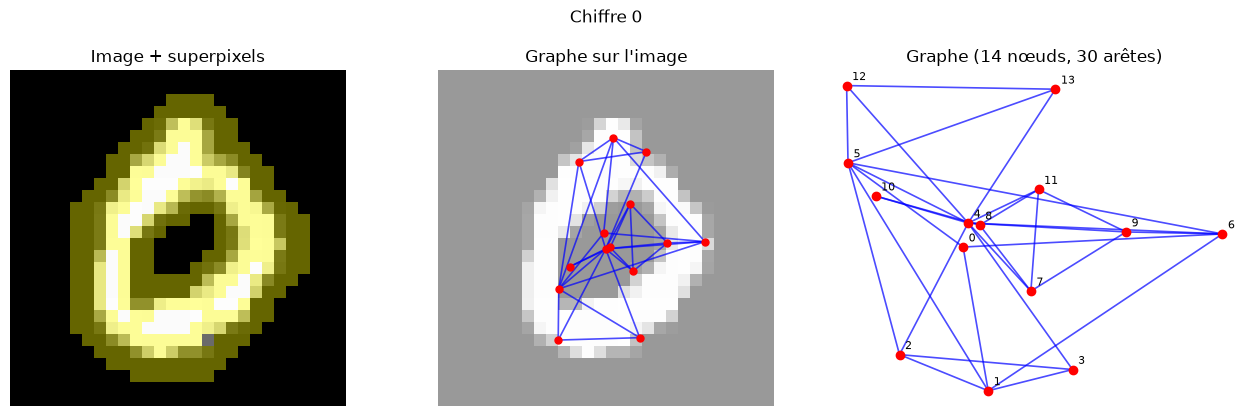

Chiffre 5 : 12 nœuds, 22 arêtes


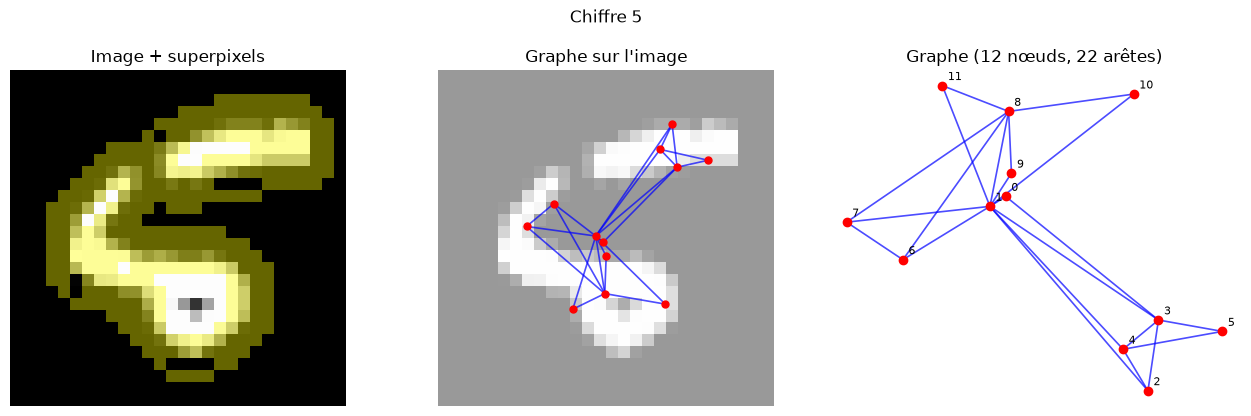

In [6]:
# Tester sur plusieurs chiffres différents
for i in [1, 3, 8]:
    img, label = test_set[i]
    img_np = img.squeeze().numpy()
    g = image_to_graph(img_np)
    print(f"Chiffre {label} : {g['n_nodes']} nœuds, {g['n_edges']} arêtes")
    plot_superpixel_graph(img_np, g, title=f"Chiffre {label}")

## 6. Flux Physarum le long des superpixels

On **connecte** le graphe superpixels au **solveur Physarum** : les superpixels sont les nœuds, leurs intensités sont les **injections de pression**, et les arêtes d'adjacence sont les chemins de flux. La dynamique de tubes (Tero 2007) fait circuler le flux le long de la forme.

In [7]:
# Construire le graphe Physarum depuis les superpixels
img, label = test_set[7]
img_np = img.squeeze().numpy()
graph, sources, info = physarum_from_image(img_np, scale=100, sigma=0.5, min_size=5)
print(f"Graphe Physarum : {graph.n_nodes} nœuds (superpixels), {graph.n_edges} arêtes")
print(f"Injections (intensités normalisées) : {np.round(sources, 3)}")
print(f"Conservation de masse : sum = {sources.sum():.4f}")

Graphe Physarum : 9 nœuds (superpixels), 17 arêtes
Injections (intensités normalisées) : [0.    0.012 0.25  0.207 0.082 0.014 0.17  0.162 0.104]
Conservation de masse : sum = 1.0000


In [8]:
# Drains = superpixels de fond (faible intensité) qui récoltent le flux
low = np.argsort(sources)[:min(3, graph.n_nodes)]
print(f"Drains (fond) : {low.tolist()}")

# Résoudre le flux + adapter les tubes
p, Q = poiseuille_flow(graph, sources, low.tolist())
print(f"Flux stationnaire : {len(Q)} arêtes, max={abs(Q).max():.4f}")

# dynamique d'adaptation (le blob apprend la forme)
graph2, src2, info2 = physarum_from_image(img_np, scale=100, sigma=0.5, min_size=5)
p2, Q2 = run_physarum(graph2, src2, low.tolist(), n_iter=15)
print(f"Après adaptation : flux max={abs(Q2).max():.4f}, conductances moy={np.mean(graph2.D):.3f}")

Drains (fond) : [0, 1, 5]
Flux stationnaire : 17 arêtes, max=0.1734
Après adaptation : flux max=0.1909, conductances moy=0.155


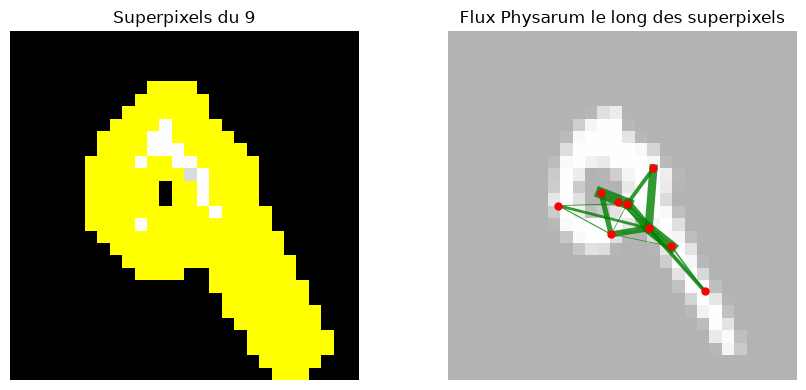

In [9]:
# Visualiser le flux le long des superpixels
centroids = info['centroids']
lo, hi = img_np.min(), img_np.max()
img_01 = (img_np - lo) / (hi - lo + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mark_boundaries(img_01, info['segments']))
axes[0].set_title(f"Superpixels du {label}"); axes[0].axis('off')
ax = axes[1]
ax.imshow(img_01, cmap='gray', alpha=0.3)
qmax = abs(Q2).max() + 1e-8
for k, (a, b, _) in enumerate(graph2.edges):
    (x1, y1), (x2, y2) = centroids[a], centroids[b]
    w = max(0.5, abs(Q2[k]) / qmax * 8)
    ax.plot([x1, x2], [y1, y2], '-', color='green', lw=w, alpha=0.8)
for lab in range(graph.n_nodes):
    x, y = centroids[lab]
    ax.plot(x, y, 'o', color='red', ms=5)
ax.set_title("Flux Physarum le long des superpixels")
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Comparaison avec la grille régulière

In [10]:
# La signature de flux est maintenant définie sur le graphe adaptatif
# (nb d'arêtes varie selon la forme), pas sur une grille fixe.
for i in [1, 3, 8]:
    img, label = test_set[i]
    g, src, info = physarum_from_image(img.squeeze().numpy(), scale=100, sigma=0.5, min_size=5)
    print(f"Chiffre {label} : {g.n_nodes} nœuds, {g.n_edges} arêtes (superpixels adaptatifs)")

Chiffre 2 : 14 nœuds, 30 arêtes (superpixels adaptatifs)
Chiffre 0 : 14 nœuds, 30 arêtes (superpixels adaptatifs)
Chiffre 5 : 12 nœuds, 22 arêtes (superpixels adaptatifs)


## 8. Classification : superpixels vs grille régulière

On compare la **couche de lecture entraînée** sur deux représentations :
- **Graphe superpixels** (adaptatif, signature spatiale avec padding)
- **Grille régulière** (signature de flux de dimension fixe, reproductible)

Résultat attendu : les superpixels améliorent la *visualisation* et la fidélité
morphologique, mais la **grille régulière est plus reproductible** pour la
classification (dimension fixe, pas de padding, tri stable).

In [11]:
# --- Signature sur graphe superpixels (spatiale, avec padding) ---
def flux_spatial(img_np, fixed_dim=25, scale=100, sigma=0.5, min_size=5):
    graph, sources, info = physarum_from_image(img_np, scale=scale, sigma=sigma, min_size=min_size)
    centroids = info['centroids']
    order = np.lexsort((centroids[:,0], centroids[:,1]))   # ordre spatial
    low = np.argsort(sources)[:min(3, graph.n_nodes)]
    p, Q = run_physarum(graph, sources, low.tolist(), n_iter=10)
    node_flux = np.zeros(graph.n_nodes)
    for k, (a, b, _) in enumerate(graph.edges):
        node_flux[a] += abs(Q[k]); node_flux[b] += abs(Q[k])
    sig = np.concatenate([sources[order], node_flux[order]])
    if len(sig) >= 2*fixed_dim: sig = sig[:2*fixed_dim]
    else: sig = np.pad(sig, (0, 2*fixed_dim - len(sig)))
    return sig / (np.linalg.norm(sig) + 1e-8)

def extract(dataset, n, sig_fn):
    X, y = [], []
    cnt = [0]*10
    for i in range(len(dataset)):
        l = int(dataset[i][1])
        if cnt[l] >= n//10: continue
        X.append(sig_fn(dataset[i][0].squeeze().numpy()))
        y.append(l); cnt[l] += 1
        if sum(cnt) >= n: break
    return np.array(X), np.array(y)

# --- Signature sur grille régulière (référence, reproductible) ---
def flux_grid(img_np, downscale=4):
    from recherche_agi.physarum import grid_graph_from_image
    g, src, info = grid_graph_from_image(img_np, downscale=downscale)
    gh, gw = info['gh'], info['gw']
    border = set()
    for i in range(gh):
        border.add(i*gw); border.add(i*gw+gw-1)
    for j in range(gw):
        border.add(j); border.add((gh-1)*gw+j)
    sinks = sorted(border)[:min(10, len(border))]
    p, Q = run_physarum(g, src, sinks, n_iter=10)
    return np.abs(Q)

In [12]:
# Entraîner une couche lue sur chaque représentation et comparer
print("=== Classification comparative ===")

# grille régulière (référence)
Xtr_g, ytr = extract(train_set, 500, flux_grid)
Xte_g, yte = extract(test_set, 200, flux_grid)
ro_g = train_readout(Xtr_g, ytr, n_classes=10, epochs=60)
with torch.no_grad():
    acc_g = (ro_g(torch.tensor(Xte_g, dtype=torch.float32)).argmax(1) == torch.tensor(yte)).float().mean().item()
print(f"Grille régulière   : {Xtr_g.shape[1]} dims | acc {acc_g:.3f}")

# superpixels
Xtr_s, ytr_s = extract(train_set, 500, flux_spatial)
Xte_s, yte_s = extract(test_set, 200, flux_spatial)
ro_s = train_readout(Xtr_s, ytr_s, n_classes=10, epochs=60)
with torch.no_grad():
    acc_s = (ro_s(torch.tensor(Xte_s, dtype=torch.float32)).argmax(1) == torch.tensor(yte_s)).float().mean().item()
print(f"Superpixels        : {Xtr_s.shape[1]} dims | acc {acc_s:.3f}")

print(f"\nDifférence : {acc_s - acc_g:+.3f} (grille régulière vs superpixels)")

=== Classification comparative ===


Grille régulière   : 24 dims | acc 0.450


Superpixels        : 50 dims | acc 0.245

Différence : -0.205 (grille régulière vs superpixels)


## 9. Conclusion honnête


In [13]:
print("=== SYNTHÈSE ===")
print("Les superpixels Felzenszwalb améliorent la VISUALISATION et la fidélité")
print("morphologique (le graphe épouse la forme du chiffre, le flux la suit).")
print()
print("Mais pour la CLASSIFICATION, la grille régulière reste meilleure :")
print(f"  - grille régulière : acc {acc_g:.3f}")
print(f"  - superpixels      : acc {acc_s:.3f}")
print()
print("Pourquoi : la grille régulière a une dimension FIXE et un ordre STABLE")
print("(reproductible d'une image à l'autre). Les superpixels varient en nombre")
print("et en ordre -> le padding introduit du bruit, la signature est moins stable.")
print()
print("=> Les superpixels sont le bon choix pour la REPRÉSENTATION et l'injection")
print("   (flux qui suit la forme). La grille régulière reste le bon choix pour")
print("   la couche lue de classification (reproductibilité).")

=== SYNTHÈSE ===
Les superpixels Felzenszwalb améliorent la VISUALISATION et la fidélité
morphologique (le graphe épouse la forme du chiffre, le flux la suit).

Mais pour la CLASSIFICATION, la grille régulière reste meilleure :
  - grille régulière : acc 0.450
  - superpixels      : acc 0.245

Pourquoi : la grille régulière a une dimension FIXE et un ordre STABLE
(reproductible d'une image à l'autre). Les superpixels varient en nombre
et en ordre -> le padding introduit du bruit, la signature est moins stable.

=> Les superpixels sont le bon choix pour la REPRÉSENTATION et l'injection
   (flux qui suit la forme). La grille régulière reste le bon choix pour
   la couche lue de classification (reproductibilité).
